# 05. Appendix B robustness and implementation diagnostics

This notebook produces the supplementary artifacts requested in Appendix B. It covers daily replay concentration, replay-regret stability, ranking sensitivity, catalog-size sensitivity, support-resolution diagnostics, pairwise boundary support, shortlist sensitivity, alternative decision rules, expanded segment safety, transfer robustness, response-gap sensitivity, stress tests, and implementation details.

In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
        CODE_ROOT = candidate
        break
    if (candidate / "code" / "src").is_dir() and (candidate / "code" / "notebooks").is_dir():
        CODE_ROOT = candidate / "code"
        break
else:
    raise RuntimeError("Could not find the project code root.")

sys.path.insert(0, str(CODE_ROOT / "src"))

from IPython.display import Image, display

from config import ExperimentConfig, ProjectPaths
from paper_experiments import (
    build_ipinyou_panels,
    run_appendix_b_diagnostics,
    run_conservative_shortlist,
    run_data_audit,
    run_support_localized_threshold_resolution,
    run_validation_readiness,
)
from progress import ProgressLogger

paths = ProjectPaths.from_repo_root(CODE_ROOT)
paths.ensure()
config = ExperimentConfig(full_run=True)
progress = ProgressLogger(enabled=True)
print(f"Code root: {CODE_ROOT}")
print(f"Data archive: {paths.ipinyou_archive}")
print(f"Artifacts: {paths.artifact_dir}")

Code root: <repo>
Data archive: <repo>/data/archive.zip
Artifacts: <repo>/artifacts


[03:01:26] >> Running Appendix B diagnostics.
[03:01:26] >> Running Section 5.1 conservative shortlist construction.
[03:01:28]    Using cached replay artifacts for 02_season2.
[03:01:29] OK Section 5.1 artifacts are ready. (2.6s elapsed)
[03:01:29] >> Running Section 5.2 support-localized threshold resolution.
[03:01:29] >> Running Section 5.1 conservative shortlist construction.
[03:01:30]    Using cached replay artifacts for 02_season2.
[03:01:31] OK Section 5.1 artifacts are ready. (5.0s elapsed)
[03:05:22] OK Section 5.2 artifacts are ready. (235.8s elapsed)
[03:05:22] >> Running Section 5.3 validation-readiness experiment.
[03:05:23]    Using cached Season 2 replay effects: 02_season2_replay_policy_effects.csv.
[03:05:23]    Replaying policies on ipinyou_season3_20131019.parquet.
[03:05:24]    Replaying policies on ipinyou_season3_20131020.parquet.
[03:05:24]    Replaying policies on ipinyou_season3_20131021.parquet.
[03:05:26]    Replaying policies on ipinyou_season3_20131022.pa

,catalog_size,leader_policy_id,leader_lower_bound_lift,bonferroni_z
0,3,hybrid_q75_if_gap_100,0.421496,2.393980
1,5,hybrid_q75_if_gap_100,0.417239,2.575829
2,10,hybrid_q75_if_gap_100,0.411828,2.807034
3,15,hybrid_q75_if_gap_100,0.408828,2.935199
4,19,hybrid_q75_if_gap_100,0.407129,3.007787



05_shortlist_size_sensitivity.csv


,shortlist_tolerance,shortlist_size,dominated_count,certified_count,unresolved_count,shortlist_policy_ids
0,0.000,2,17,1,1,"hybrid_q75_if_gap_100, min_positive_floor_q75"
1,0.005,2,17,1,1,"hybrid_q75_if_gap_100, min_positive_floor_q75"
2,0.010,2,17,1,1,"hybrid_q75_if_gap_100, min_positive_floor_q75"
3,0.020,2,17,1,1,"hybrid_q75_if_gap_100, min_positive_floor_q75"
4,0.050,2,17,1,1,"hybrid_q75_if_gap_100, min_positive_floor_q75"



05_rank_stability.csv


,comparison,spearman_rank_correlation,top5_overlap
0,season2_vs_season3,0.987709,4



05_response_gap_sensitivity.csv


,leader_policy_id,runner_up_policy_id,season2_replay_margin,hypothetical_pairwise_response_gap,ranking_preserved_under_symmetric_gap
0,hybrid_q75_if_gap_100,min_positive_floor_q75,0.121529,0.000,True
1,hybrid_q75_if_gap_100,min_positive_floor_q75,0.121529,0.025,True
2,hybrid_q75_if_gap_100,min_positive_floor_q75,0.121529,0.050,True
3,hybrid_q75_if_gap_100,min_positive_floor_q75,0.121529,0.075,False
4,hybrid_q75_if_gap_100,min_positive_floor_q75,0.121529,0.100,False



05_implementation_manifest.csv


,artifact,description,row_count
0,policy_catalog,"Logged baseline, uniform increases, quantile f...",19
1,season2_panel,Development replay panel built from iPinYou tr...,53289330
2,season3_panel,Frozen out-of-time replay panel built from iPi...,10566743


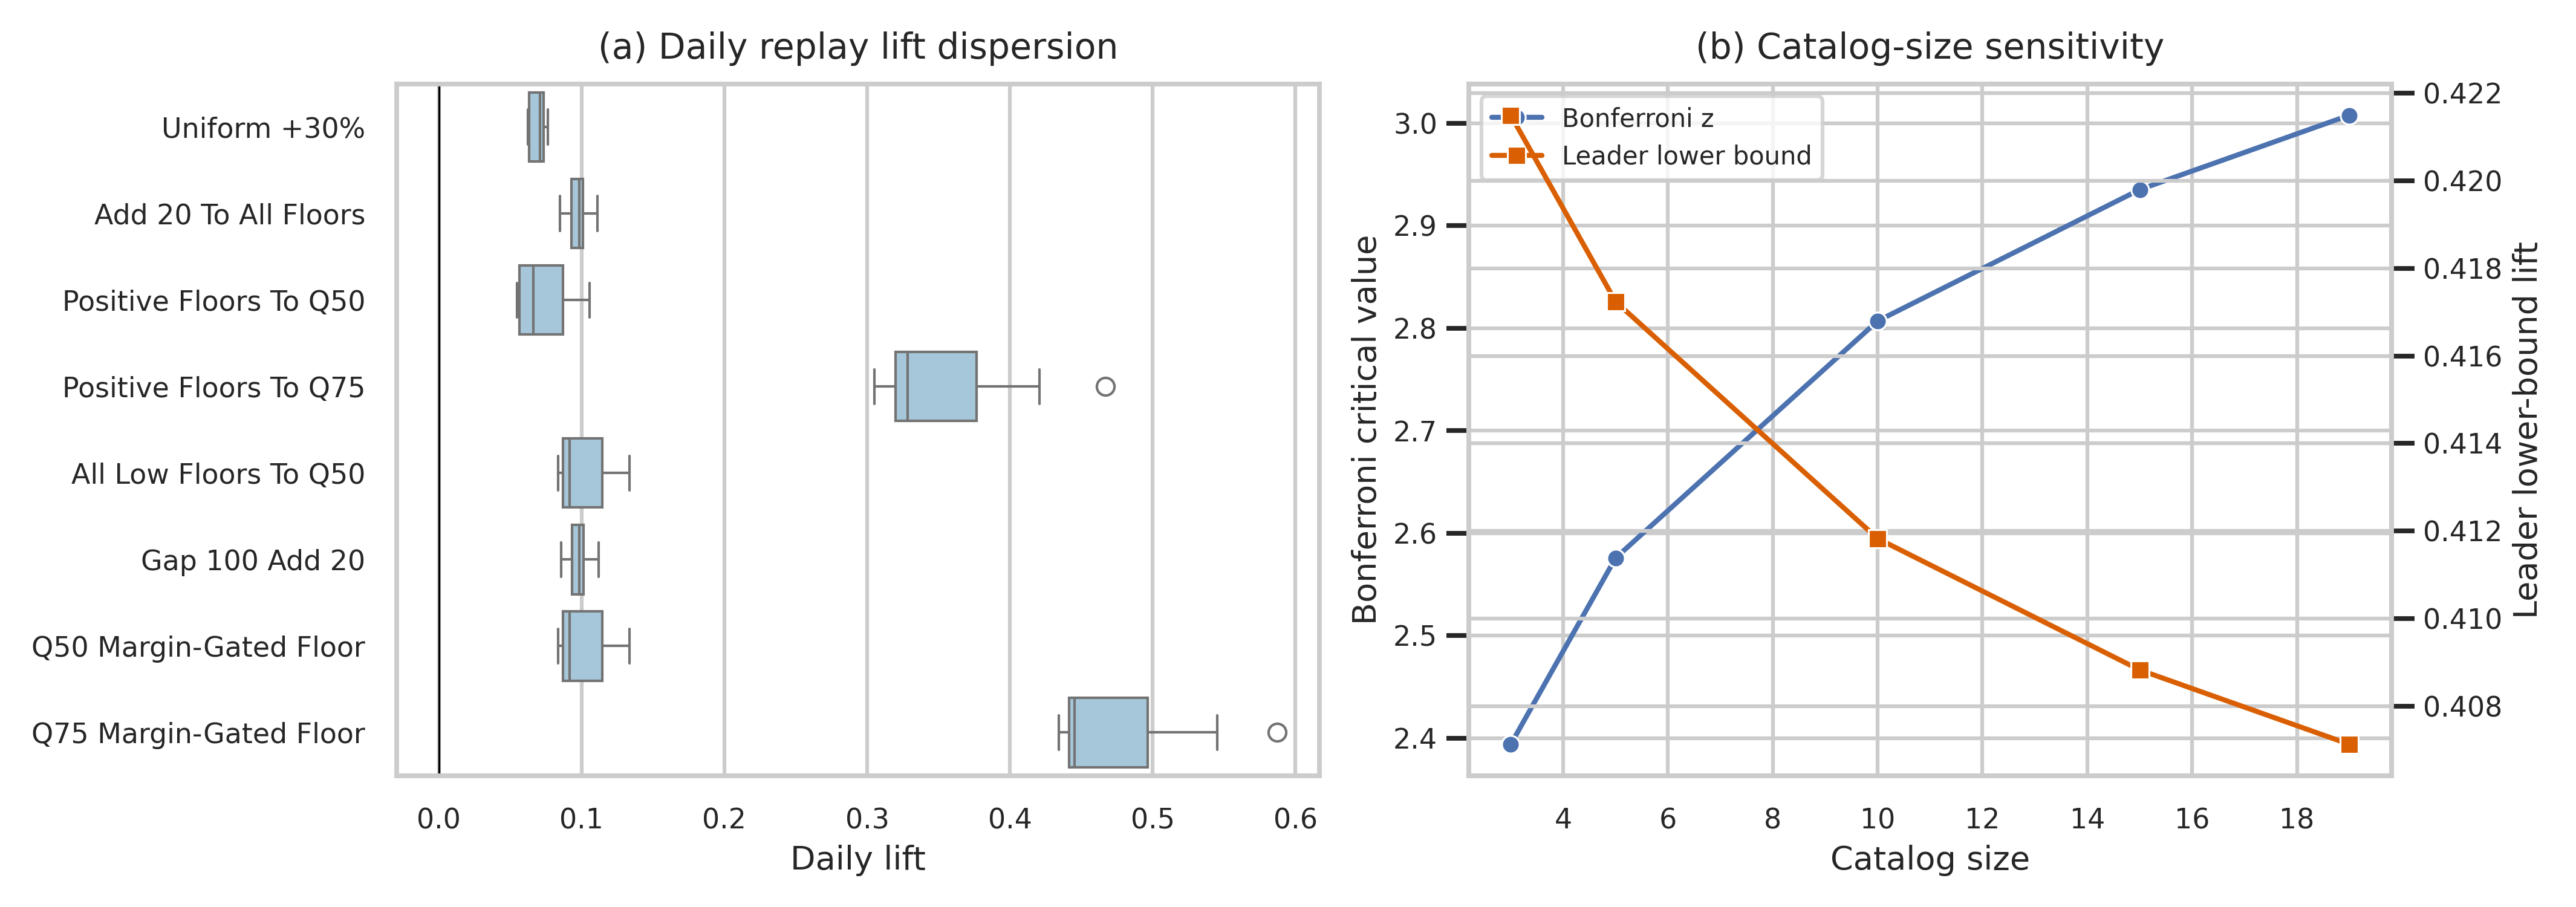

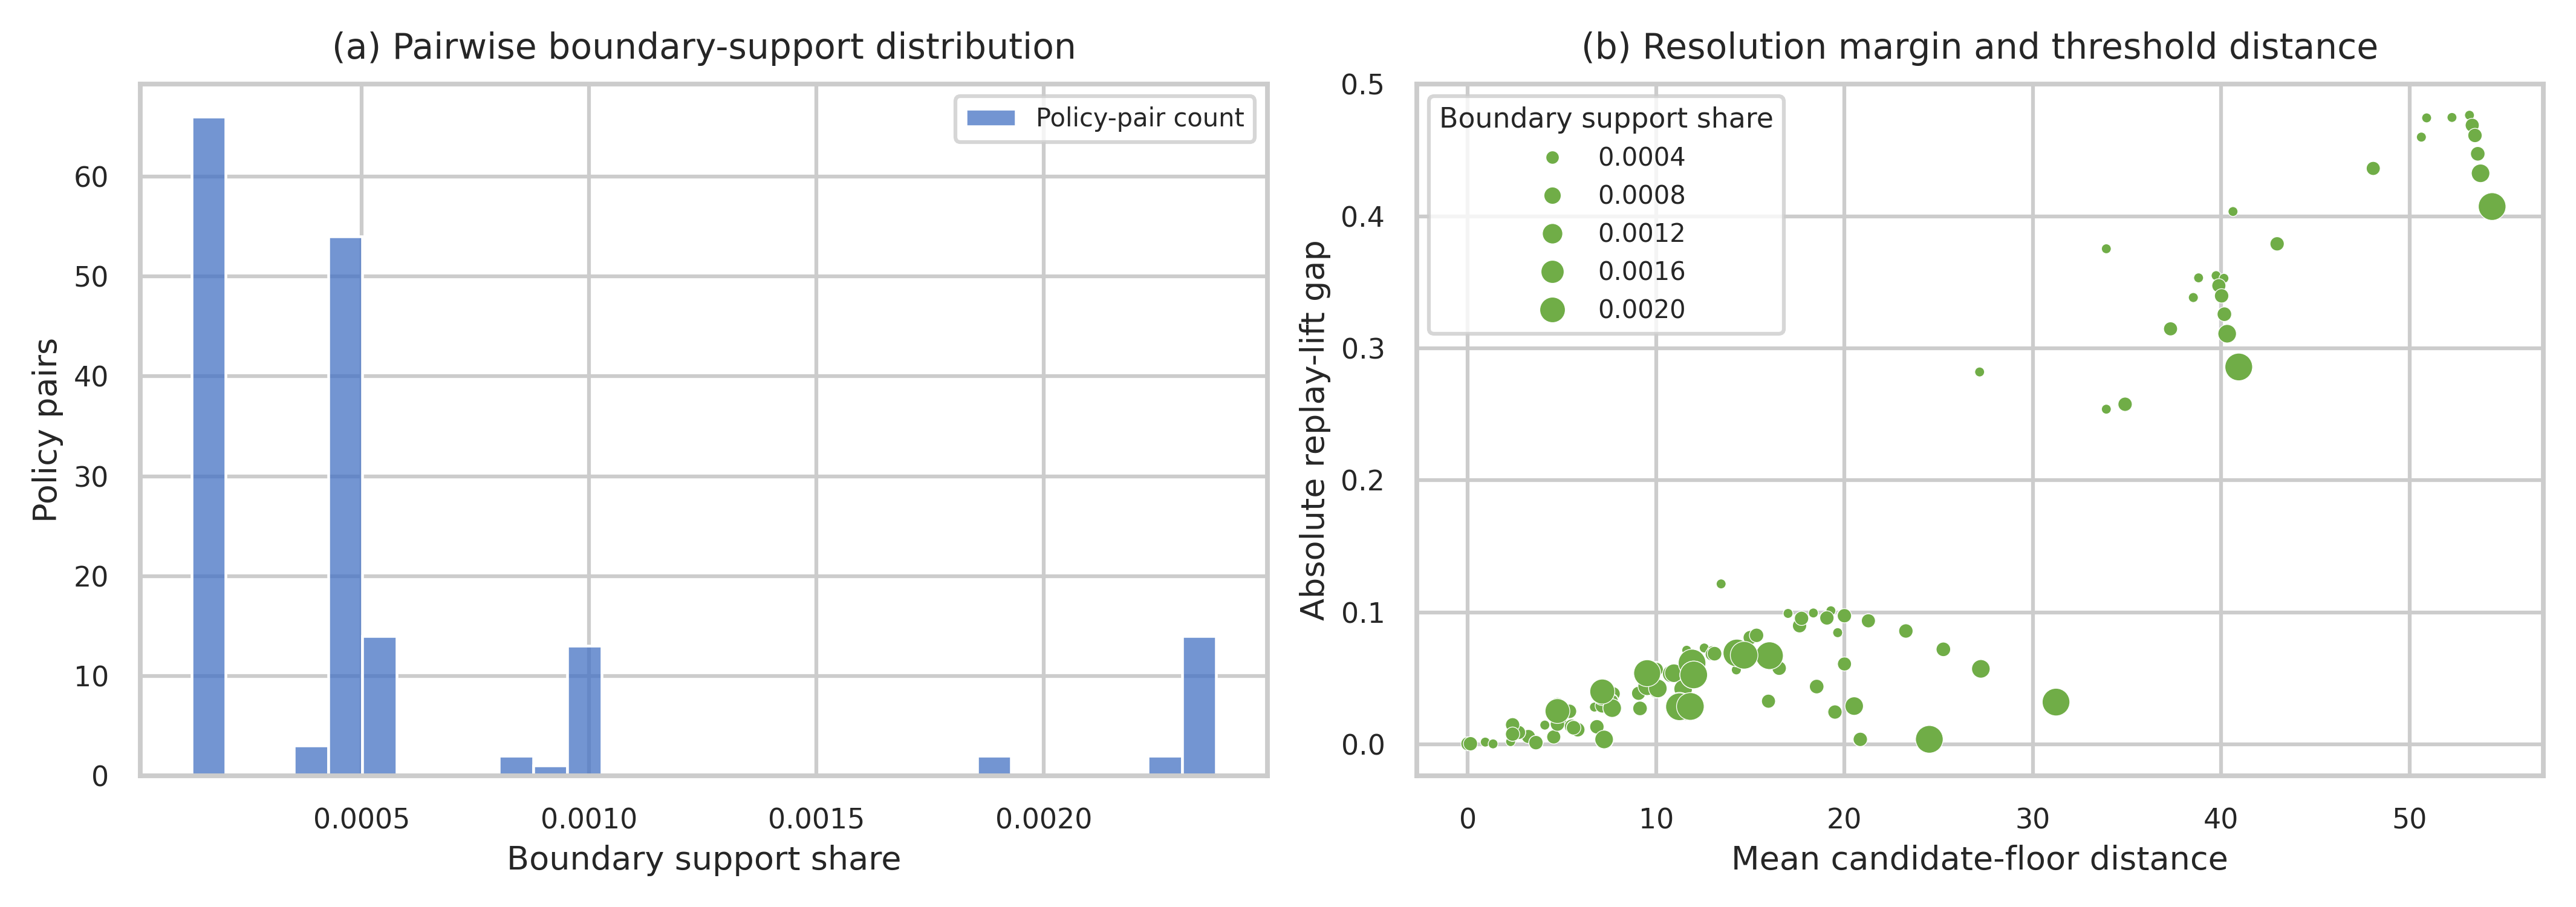

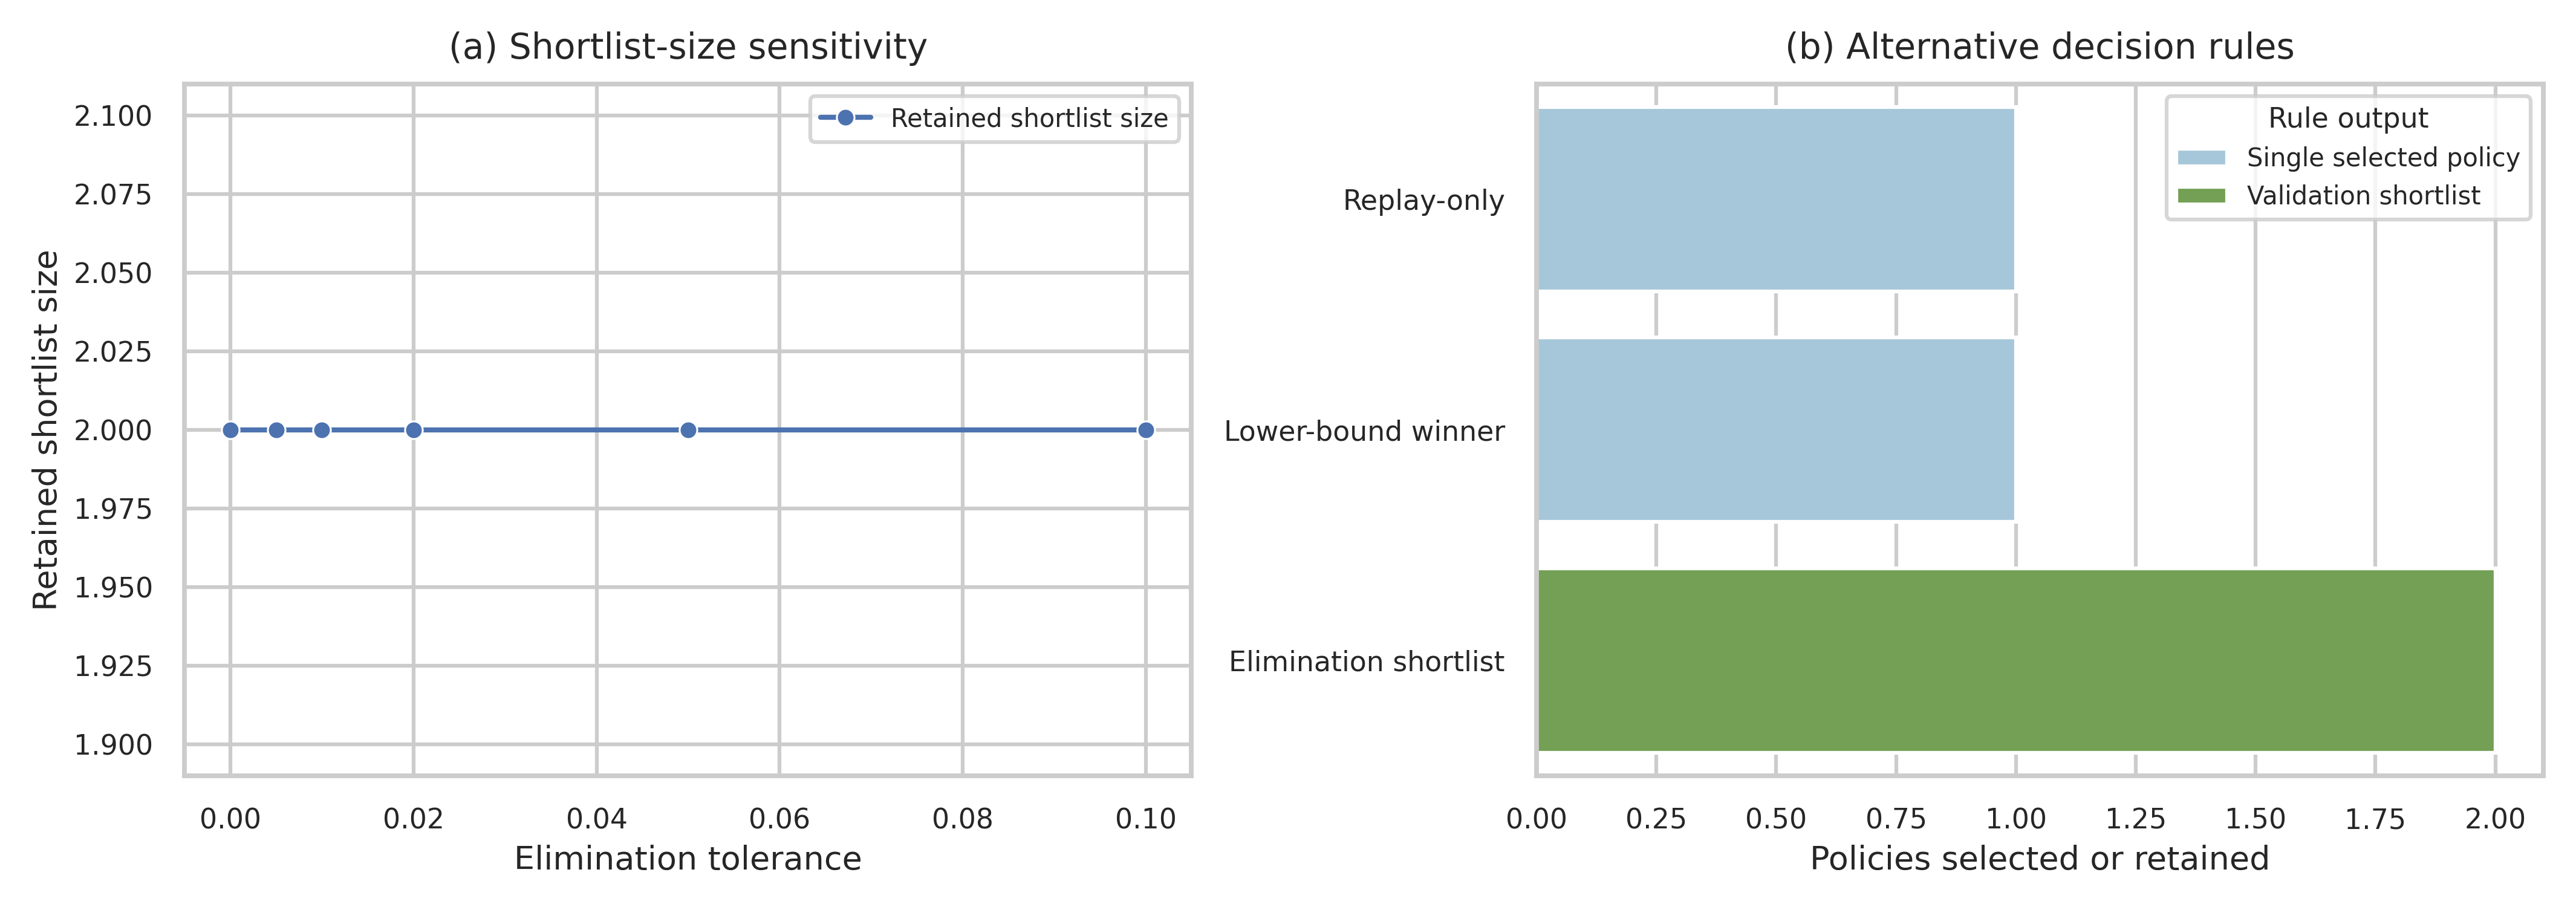

In [2]:
artifacts = run_appendix_b_diagnostics(paths, config, progress)

for name in [
    "05_catalog_size_sensitivity.csv",
    "05_shortlist_size_sensitivity.csv",
    "05_rank_stability.csv",
    "05_response_gap_sensitivity.csv",
    "05_implementation_manifest.csv",
]:
    print(f"\n{name}")
    display(artifacts[name].head())

for key in ["appendix_replay_figure", "appendix_support_figure", "appendix_decision_figure"]:
    display(Image(filename=str(artifacts[key])))